In [1]:
from pathlib import Path
import json
import math


import fitz  # pymupdf
import pdfplumber
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from IPython.display import display

import torch
from transformers import AutoImageProcessor, TableTransformerForObjectDetection
from PIL import Image, ImageDraw, ImageFont
import torchvision.transforms.functional as TF

from dataclasses import dataclass, field
from typing import List, Dict, Any, Tuple, Optional


# ── Paths ────────────────────────────────────────────────────────────────────
DOCS_DIR   = Path("documents")
PDF_PATH   = DOCS_DIR / "Session 06 - Regular Expressions.pdf"
OUTPUT_DIR = Path("output")
IMG_DIR    = OUTPUT_DIR / "images"

IMG_DIR.mkdir(parents=True, exist_ok=True)

print(f"PDF: {PDF_PATH}  (exists={PDF_PATH.exists()})")
print(f"Image output dir: {IMG_DIR}")

/Users/borisgans/personal/pdf-extraction/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/borisgans/personal/pdf-extraction/.venv/lib/python3.11/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/Users/borisgans/personal/pdf-extraction/.venv/lib/python3.11/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


PDF: documents/Session 06 - Regular Expressions.pdf  (exists=True)
Image output dir: output/images


/Users/borisgans/personal/pdf-extraction/.venv/lib/python3.11/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [2]:
TATR_DETECT_MODEL = "microsoft/table-transformer-detection"
TATR_STRUCT_MODEL = "microsoft/table-transformer-structure-recognition"

TATR_THRESHOLD = 0.85
STRUCT_THRESHOLD = 0.60
TATR_DPI = 150

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


print("Loading detection model...")
detect_processor = AutoImageProcessor.from_pretrained(TATR_DETECT_MODEL)
detect_model = TableTransformerForObjectDetection.from_pretrained(TATR_DETECT_MODEL).to(DEVICE)
detect_model.eval()

print("Loading structure model...")
struct_processor = AutoImageProcessor.from_pretrained(TATR_STRUCT_MODEL)
struct_model = TableTransformerForObjectDetection.from_pretrained(TATR_STRUCT_MODEL).to(DEVICE)
struct_model.eval()

print(f"Models ready on {DEVICE}.")

Loading detection model...


Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration.
The `max_size` parameter is deprecated and will be removed in v4.26. Please specify in `size['longest_edge'] instead`.
Some weights of the model checkpoint at microsoft/table-transformer-detection were not used when initializing TableTransformerForObjectDetection: ['model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing TableTransformerForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TableTransformerForObject

Loading structure model...


Some weights of the model checkpoint at microsoft/table-transformer-structure-recognition were not used when initializing TableTransformerForObjectDetection: ['model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing TableTransformerForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TableTransformerForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Models ready on cpu.


In [3]:
@dataclass
class Detection:
    label: str
    score: float
    box: List[int]   # [x0, y0, x1, y1]


@dataclass
class TableResult:
    page_index: int
    table_index: int
    table_box_page_px: List[int]
    table_box_crop: Image.Image
    dataframe: pd.DataFrame
    raw_cells: List[List[str]]
    structure_objects: List[Detection]
    # quality / provenance metadata
    detection_score: float = 0.0
    structure_quality: float = 0.0
    column_source: str = "unknown"   # "tatr" | "external_header" | "body_text_cluster" | "generic"
    header_strategy: str = "unknown"
    raw_above_header: List[str] = field(default_factory=list)


def render_page_pil(doc: fitz.Document, pg_idx: int, dpi: int = TATR_DPI) -> Image.Image:
    page = doc[pg_idx]
    pix = page.get_pixmap(matrix=fitz.Matrix(dpi / 72, dpi / 72), alpha=False)
    return Image.frombytes("RGB", [pix.width, pix.height], pix.samples)


def scale_pdf_to_image_rect(rect_pdf: fitz.Rect, dpi: int) -> List[int]:
    scale = dpi / 72.0
    return [
        round(rect_pdf.x0 * scale),
        round(rect_pdf.y0 * scale),
        round(rect_pdf.x1 * scale),
        round(rect_pdf.y1 * scale),
    ]


def scale_image_to_pdf_box(box_px: List[int], dpi: int) -> fitz.Rect:
    scale = 72.0 / dpi
    x0, y0, x1, y1 = box_px
    return fitz.Rect(x0 * scale, y0 * scale, x1 * scale, y1 * scale)


def clip_box(box: List[int], width: int, height: int) -> List[int]:
    x0, y0, x1, y1 = box
    return [
        max(0, min(x0, width - 1)),
        max(0, min(y0, height - 1)),
        max(0, min(x1, width - 1)),
        max(0, min(y1, height - 1)),
    ]


def iob(inner: List[int], outer: List[int]) -> float:
    """
    Intersection over box area of `inner`.
    Useful for checking if a word is mostly inside a cell.
    """
    ix0 = max(inner[0], outer[0])
    iy0 = max(inner[1], outer[1])
    ix1 = min(inner[2], outer[2])
    iy1 = min(inner[3], outer[3])

    iw = max(0, ix1 - ix0)
    ih = max(0, iy1 - iy0)
    inter = iw * ih

    inner_area = max(1, (inner[2] - inner[0]) * (inner[3] - inner[1]))
    return inter / inner_area


def box_center(box: List[int]) -> Tuple[float, float]:
    x0, y0, x1, y1 = box
    return ((x0 + x1) / 2.0, (y0 + y1) / 2.0)


def sort_top_to_bottom(dets: List[Detection]) -> List[Detection]:
    return sorted(dets, key=lambda d: (d.box[1], d.box[0]))


def sort_left_to_right(dets: List[Detection]) -> List[Detection]:
    return sorted(dets, key=lambda d: (d.box[0], d.box[1]))



In [4]:

def overlaps_any(box: List[int], regions: List[Detection], min_iob: float = 0.3) -> bool:
    return any(iob(box, r.box) >= min_iob for r in regions)


def pad_box(box: List[int], pad: int, width: int, height: int) -> List[int]:
    x0, y0, x1, y1 = box
    return [
        max(0, x0 - pad),
        max(0, y0 - pad),
        min(width, x1 + pad),
        min(height, y1 + pad),
    ]


def merge_nearby_detections(
    dets: List[Detection],
    axis: str,
    tol: int = 8
) -> List[Detection]:
    """
    Merge nearly duplicate row/column detections by center position.
    axis='x' for columns, axis='y' for rows.
    """
    if not dets:
        return []

    if axis == "x":
        dets = sorted(dets, key=lambda d: (d.box[0] + d.box[2]) / 2.0)
        center = lambda d: (d.box[0] + d.box[2]) / 2.0
    else:
        dets = sorted(dets, key=lambda d: (d.box[1] + d.box[3]) / 2.0)
        center = lambda d: (d.box[1] + d.box[3]) / 2.0

    merged = [Detection(label=dets[0].label, score=dets[0].score, box=dets[0].box[:])]

    for d in dets[1:]:
        prev = merged[-1]
        if abs(center(d) - center(prev)) <= tol:
            prev.box = [
                min(prev.box[0], d.box[0]),
                min(prev.box[1], d.box[1]),
                max(prev.box[2], d.box[2]),
                max(prev.box[3], d.box[3]),
            ]
            prev.score = max(prev.score, d.score)
        else:
            merged.append(Detection(label=d.label, score=d.score, box=d.box[:]))

    return merged


def is_sane_header_detection(
    header_boxes: List[Detection],
    rows: List[Detection],
    cols: List[Detection],
    table_width: int,
    min_header_score: float = 0.75
) -> bool:
    """
    Decide whether explicit table-column-header detections are trustworthy enough to use.
    """
    if not header_boxes or not rows or not cols:
        return False

    good_headers = [h for h in header_boxes if h.score >= min_header_score]
    if not good_headers:
        return False

    first_row_top = min(r.box[1] for r in rows)

    # Header should mostly live above the first body row.
    above_first_row = 0
    for h in good_headers:
        if h.box[3] <= first_row_top + 6:
            above_first_row += 1

    # Header boxes should span a meaningful width of the table.
    total_header_width = sum(max(0, h.box[2] - h.box[0]) for h in good_headers)
    wide_enough = total_header_width >= 0.4 * table_width

    return above_first_row >= 1 and wide_enough


def extract_table_words_local(
    page_words: List[Dict],
    table_box_page: List[int],
    rows_local: List[Detection],
    cols_local: List[Detection],
    min_table_iob: float = 0.5,
    min_row_iob: float = 0.15,
    min_col_iob: float = 0.15,
) -> List[Dict]:
    """
    Keep only words that are inside the table and overlap at least one row and one column.
    Convert them from page coords to table-local coords.
    """
    x0, y0, x1, y1 = table_box_page
    table_words = []

    for w in page_words:
        wb = w["box"]

        if iob(wb, table_box_page) < min_table_iob:
            continue

        local_box = [wb[0] - x0, wb[1] - y0, wb[2] - x0, wb[3] - y0]

        has_row = any(iob(local_box, r.box) >= min_row_iob for r in rows_local)
        has_col = any(iob(local_box, c.box) >= min_col_iob for c in cols_local)

        if has_row and has_col:
            table_words.append({
                "text": w["text"],
                "box": local_box,
            })

    return table_words


def get_top_header_band(rows: List[Detection], table_width: int, table_height: int, band_pad: int = 2) -> Optional[List[int]]:
    """
    Build header region as everything above the first detected row.
    Coordinates are table-local.
    """
    if not rows:
        return None

    first_row_top = min(r.box[1] for r in rows)
    if first_row_top <= 2:
        return None

    return [0, 0, table_width, max(0, first_row_top - band_pad)]


def build_headers_from_regions(
    words: List[Dict],
    header_regions: List[Detection],
    cols: List[Detection],
    min_region_iob: float = 0.25,
    min_col_iob: float = 0.2,
) -> List[str]:
    """
    Assign words from explicit header regions to columns.
    """
    headers_by_col = [[] for _ in range(len(cols))]

    for w in words:
        wbox = w["box"]
        text = w["text"]

        if not overlaps_any(wbox, header_regions, min_iob=min_region_iob):
            continue

        hits = [(iob(wbox, c.box), idx) for idx, c in enumerate(cols)]
        hits = [h for h in hits if h[0] >= min_col_iob]
        if not hits:
            continue

        best_col = max(hits, key=lambda x: x[0])[1]
        headers_by_col[best_col].append((wbox[1], wbox[0], text))

    headers = []
    for i, items in enumerate(headers_by_col):
        items = sorted(items, key=lambda x: (x[0], x[1]))
        txt = " ".join(t for _, _, t in items).strip()
        headers.append(txt if txt else f"col_{i}")

    return headers


def build_headers_from_top_band(
    words: List[Dict],
    header_band: List[int],
    cols: List[Detection],
    min_band_iob: float = 0.15,
    min_col_iob: float = 0.2,
) -> List[str]:
    """
    Assign words from the inferred top header band to columns.
    header_band is [x0,y0,x1,y1] in table-local coords.
    """
    headers_by_col = [[] for _ in range(len(cols))]

    for w in words:
        wbox = w["box"]
        text = w["text"]

        if iob(wbox, header_band) < min_band_iob:
            continue

        hits = [(iob(wbox, c.box), idx) for idx, c in enumerate(cols)]
        hits = [h for h in hits if h[0] >= min_col_iob]
        if not hits:
            continue

        best_col = max(hits, key=lambda x: x[0])[1]
        headers_by_col[best_col].append((wbox[1], wbox[0], text))

    headers = []
    for i, items in enumerate(headers_by_col):
        items = sorted(items, key=lambda x: (x[0], x[1]))
        txt = " ".join(t for _, _, t in items).strip()
        headers.append(txt if txt else f"col_{i}")

    return headers


def header_quality_score(headers: List[str]) -> float:
    """
    Simple quality score: more non-empty, short textual headers score better.
    """
    if not headers:
        return 0.0

    non_empty = [h.strip() for h in headers if h.strip()]
    if not non_empty:
        return 0.0

    shortish = sum(len(h) <= 40 for h in non_empty) / len(non_empty)
    alphaish = sum(any(ch.isalpha() for ch in h) for h in non_empty) / len(non_empty)
    numeric_heavy = sum(sum(ch.isdigit() for ch in h) > max(1, len(h) // 3) for h in non_empty) / len(non_empty)

    coverage = len(non_empty) / len(headers)
    score = 0.45 * coverage + 0.30 * shortish + 0.30 * alphaish - 0.35 * numeric_heavy
    return score


def assign_words_to_grid_excluding_header(
    words: List[Dict],
    rows: List[Detection],
    cols: List[Detection],
    header_regions: Optional[List[Detection]] = None,
    header_band: Optional[List[int]] = None,
    min_row_iob: float = 0.15,
    min_col_iob: float = 0.15,
) -> List[List[str]]:
    """
    Assign non-header words into row/col cells.
    """
    grid = [[[] for _ in range(len(cols))] for _ in range(len(rows))]

    for w in words:
        wbox = w["box"]
        text = w["text"]

        if header_regions and overlaps_any(wbox, header_regions, min_iob=0.2):
            continue
        if header_band and iob(wbox, header_band) >= 0.15:
            continue

        row_hits = [(iob(wbox, r.box), idx) for idx, r in enumerate(rows)]
        row_hits = [h for h in row_hits if h[0] >= min_row_iob]
        if not row_hits:
            continue

        col_hits = [(iob(wbox, c.box), idx) for idx, c in enumerate(cols)]
        col_hits = [h for h in col_hits if h[0] >= min_col_iob]
        if not col_hits:
            continue

        best_row = max(row_hits, key=lambda x: x[0])[1]
        best_col = max(col_hits, key=lambda x: x[0])[1]
        grid[best_row][best_col].append((wbox[1], wbox[0], text))

    out = []
    for row in grid:
        row_text = []
        for cell_words in row:
            cell_words = sorted(cell_words, key=lambda x: (x[0], x[1]))
            row_text.append(" ".join(t for _, _, t in cell_words).strip())
        out.append(row_text)

    return out


def choose_header_strategy(
    words: List[Dict],
    rows: List[Detection],
    cols: List[Detection],
    explicit_headers: List[Detection],
    table_width: int,
    table_height: int,
) -> Tuple[List[str], str, Optional[List[int]], Optional[List[Detection]]]:
    """
    Priority:
      1. explicit table column header detections, if sane
      2. top band above first row
      3. generic col_i
    Returns:
      headers, strategy_name, header_band, used_header_regions
    """
    header_band = None
    used_header_regions = None

    if is_sane_header_detection(explicit_headers, rows, cols, table_width):
        headers = build_headers_from_regions(words, explicit_headers, cols)
        if header_quality_score(headers) >= 0.45:
            return headers, "explicit_header_boxes", None, explicit_headers

    header_band = get_top_header_band(rows, table_width, table_height)
    if header_band is not None:
        headers = build_headers_from_top_band(words, header_band, cols)
        if header_quality_score(headers) >= 0.35:
            return headers, "top_band", header_band, None

    headers = [f"col_{i}" for i in range(len(cols))]
    return headers, "generic", None, None

# ── Box repair helpers ────────────────────────────────────────────────────────

def pad_box_sides(
    box: List[int],
    width: int,
    height: int,
    pad_left: int = 8,
    pad_top: int = 8,
    pad_right: int = 8,
    pad_bottom: int = 28,
) -> List[int]:
    """Asymmetric padding — more on the bottom where TATR boxes are typically short."""
    x0, y0, x1, y1 = box
    return [
        max(0, x0 - pad_left),
        max(0, y0 - pad_top),
        min(width, x1 + pad_right),
        min(height, y1 + pad_bottom),
    ]


def extend_table_box_down_using_words(
    table_box: List[int],
    page_words: List[Dict],
    page_height: int,
    max_extend: int = 80,
    line_gap: int = 22,
) -> List[int]:
    """
    Grow the table box downward if body text appears just below the current bottom edge.
    Only extends when the nearest word below is within `line_gap` pixels.
    """
    x0, y0, x1, y1 = table_box
    candidate_region = [x0, y1, x1, min(page_height, y1 + max_extend)]

    below_words = [w for w in page_words if iob(w["box"], candidate_region) >= 0.2]
    if not below_words:
        return table_box

    nearest_top = min(w["box"][1] for w in below_words)
    if nearest_top - y1 <= line_gap:
        new_bottom = max(w["box"][3] for w in below_words)
        return [x0, y0, x1, min(page_height, new_bottom + 6)]

    return table_box


# ── Column fallback helpers ───────────────────────────────────────────────────

def get_external_header_band(
    table_box: List[int],
    page_width: int,
    page_height: int,
    up: int = 45,
    down: int = 6,
    side_pad: int = 10,
) -> List[int]:
    """Return a band in page coords that sits just above the detected table box."""
    x0, y0, x1, y1 = table_box
    return [
        max(0, x0 - side_pad),
        max(0, y0 - up),
        min(page_width, x1 + side_pad),
        min(page_height, y0 + down),
    ]


def extract_words_in_box(
    page_words: List[Dict],
    region: List[int],
    min_iob: float = 0.2,
) -> List[Dict]:
    """Return words whose box has IoB >= min_iob with `region`. All coords in same space."""
    return [w for w in page_words if iob(w["box"], region) >= min_iob]


def _group_words_by_x_center(words: List[Dict], gap_px: int = 60) -> List[List[Dict]]:
    """Group left-to-right sorted words into horizontal clusters separated by > gap_px."""
    if not words:
        return []
    words = sorted(words, key=lambda w: (w["box"][0] + w["box"][2]) / 2.0)
    groups: List[List[Dict]] = [[words[0]]]
    for w in words[1:]:
        prev_cx = (groups[-1][-1]["box"][0] + groups[-1][-1]["box"][2]) / 2.0
        cur_cx = (w["box"][0] + w["box"][2]) / 2.0
        if abs(cur_cx - prev_cx) < gap_px:
            groups[-1].append(w)
        else:
            groups.append([w])
    return groups


def infer_columns_from_header_words(
    header_words: List[Dict],
    table_box_page: List[int],
    min_words: int = 2,
) -> List[Detection]:
    """
    Build column Detection objects from words found above the table.
    Returns boxes in table-local coordinates (origin = top-left of padded table box).
    """
    groups = _group_words_by_x_center(header_words, gap_px=60)
    if len(groups) < min_words:
        return []

    px0, py0, px1, py1 = table_box_page
    table_w = px1 - px0
    table_h = py1 - py0

    centers = []
    for g in groups:
        gx0 = min(w["box"][0] for w in g)
        gx1 = max(w["box"][2] for w in g)
        centers.append((gx0 + gx1) / 2.0)

    boundaries = [px0] + [round((centers[i] + centers[i + 1]) / 2.0) for i in range(len(centers) - 1)] + [px1]

    cols = []
    for i in range(len(boundaries) - 1):
        cx0 = boundaries[i] - px0   # table-local
        cx1 = boundaries[i + 1] - px0
        cols.append(Detection(label="inferred column", score=1.0, box=[cx0, 0, cx1, table_h]))

    return cols


def infer_header_names_from_header_words(header_words: List[Dict]) -> List[str]:
    """Return one header name per x-cluster of header words."""
    groups = _group_words_by_x_center(header_words, gap_px=60)
    names = []
    for g in groups:
        g_sorted = sorted(g, key=lambda w: (w["box"][1], w["box"][0]))
        txt = " ".join(w["text"] for w in g_sorted).strip()
        if txt:
            names.append(txt)
    return names


def infer_columns_from_body_words(
    table_box_page: List[int],
    page_words: List[Dict],
    min_cols: int = 2,
) -> List[Detection]:
    """
    Last-resort column inference from x-distribution of body words inside the table.
    Finds large gaps between word x-centers and splits into columns.
    """
    px0, py0, px1, py1 = table_box_page
    table_h = py1 - py0

    inside = [w for w in page_words if iob(w["box"], table_box_page) >= 0.3]
    if len(inside) < min_cols * 2:
        return []

    x_centers = sorted((w["box"][0] + w["box"][2]) / 2.0 for w in inside)
    if len(x_centers) < 2:
        return []

    gaps = [x_centers[i + 1] - x_centers[i] for i in range(len(x_centers) - 1)]
    mean_gap = sum(gaps) / len(gaps) if gaps else 0.0
    split_points = [px0]
    for i, gap in enumerate(gaps):
        if gap > mean_gap * 1.5:
            split_points.append(round((x_centers[i] + x_centers[i + 1]) / 2.0))
    split_points.append(px1)

    if len(split_points) - 1 < min_cols:
        return []

    cols = []
    for i in range(len(split_points) - 1):
        cx0 = split_points[i] - px0
        cx1 = split_points[i + 1] - px0
        cols.append(Detection(label="body column", score=0.7, box=[cx0, 0, cx1, table_h]))

    return cols


# ── LLM review tagging ────────────────────────────────────────────────────────

STRUCTURE_QUALITY_THRESHOLD = 0.40


def tag_table_for_review(table_dict: Dict, threshold: float = STRUCTURE_QUALITY_THRESHOLD) -> Dict:
    """
    Add `needs_review` bool and `llm_context` string to a table dict.
    Mutates in place and returns the dict.
    """
    needs_review = (
        table_dict.get("column_source") != "tatr"
        or table_dict.get("structure_quality", 0.0) < threshold
    )

    parts = []
    if table_dict.get("page_text_above"):
        parts.append("=== TEXT ABOVE TABLE ===\n" + table_dict["page_text_above"])
    if table_dict.get("raw_above_header"):
        parts.append("=== DETECTED HEADER WORDS ===\n" + ", ".join(table_dict["raw_above_header"]))
    if table_dict.get("headers"):
        parts.append("=== EXTRACTED HEADERS ===\n" + str(table_dict["headers"]))
    if table_dict.get("page_text_below"):
        parts.append("=== TEXT BELOW TABLE ===\n" + table_dict["page_text_below"])

    table_dict["needs_review"] = needs_review
    table_dict["llm_context"] = "\n\n".join(parts)
    return table_dict


In [5]:
# TATR inference

def detect_tables_tatr(page_img: Image.Image, threshold: float = TATR_THRESHOLD) -> List[Detection]:
    inputs = detect_processor(images=page_img, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = detect_model(**inputs)

    target_sizes = torch.tensor([page_img.size[::-1]], device=DEVICE)
    results = detect_processor.post_process_object_detection(
        outputs, threshold=threshold, target_sizes=target_sizes
    )[0]

    detections = []
    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        detections.append(
            Detection(
                label=detect_model.config.id2label[label.item()],
                score=round(score.item(), 3),
                box=[round(v) for v in box.tolist()],
            )
        )
    return detections


def recognize_table_structure(table_img: Image.Image, threshold: float = STRUCT_THRESHOLD) -> List[Detection]:
    inputs = struct_processor(images=table_img, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = struct_model(**inputs)

    target_sizes = torch.tensor([table_img.size[::-1]], device=DEVICE)
    results = struct_processor.post_process_object_detection(
        outputs, threshold=threshold, target_sizes=target_sizes
    )[0]

    detections = []
    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        detections.append(
            Detection(
                label=struct_model.config.id2label[label.item()],
                score=round(score.item(), 3),
                box=[round(v) for v in box.tolist()],
            )
        )
    return detections

In [6]:
# PDF text extraction

def extract_page_words_as_image_boxes(page: fitz.Page, dpi: int) -> List[Dict[str, Any]]:
    """
    Returns page words in IMAGE coordinates at the same DPI used for rendering.
    PyMuPDF words are:
    (x0, y0, x1, y1, text, block_no, line_no, word_no)
    """
    words = page.get_text("words")
    scale = dpi / 72.0

    out = []
    for w in words:
        x0, y0, x1, y1, text = w[:5]
        out.append({
            "text": text,
            "box": [
                round(x0 * scale),
                round(y0 * scale),
                round(x1 * scale),
                round(y1 * scale),
            ]
        })
    return out

In [7]:
# Structure -> grid


# def choose_rows_and_columns(structure: List[Detection]) -> Tuple[List[Detection], List[Detection], List[Detection]]:
#     groups = split_structure_objects(structure)

#     rows = sort_top_to_bottom(groups.get("table row", []))
#     cols = sort_left_to_right(groups.get("table column", []))
#     headers = sort_top_to_bottom(groups.get("table column header", []))

#     return rows, cols, headers

def split_structure_objects(structure: List[Detection]) -> Dict[str, List[Detection]]:
    groups: Dict[str, List[Detection]] = {}
    for obj in structure:
        groups.setdefault(obj.label, []).append(obj)
    return groups


def choose_rows_and_columns(
    structure: List[Detection],
    row_min_score: float = 0.45,
    col_min_score: float = 0.45,
    header_min_score: float = 0.70,
) -> Tuple[List[Detection], List[Detection], List[Detection]]:
    groups = split_structure_objects(structure)

    rows = [d for d in groups.get("table row", []) if d.score >= row_min_score]
    cols = [d for d in groups.get("table column", []) if d.score >= col_min_score]
    headers = [d for d in groups.get("table column header", []) if d.score >= header_min_score]

    rows = merge_nearby_detections(sort_top_to_bottom(rows), axis="y", tol=8)
    cols = merge_nearby_detections(sort_left_to_right(cols), axis="x", tol=8)
    headers = sort_top_to_bottom(headers)

    return rows, cols, headers



def assign_words_to_grid(
    table_words: List[Dict[str, Any]],
    rows: List[Detection],
    cols: List[Detection],
    min_iob: float = 0.5
) -> List[List[str]]:
    """
    Assign each word to best row/col by overlap.
    """
    grid = [[[] for _ in range(len(cols))] for _ in range(len(rows))]

    for word in table_words:
        wbox = word["box"]
        wtext = word["text"]

        row_candidates = []
        for r_idx, row in enumerate(rows):
            overlap = iob(wbox, row.box)
            if overlap >= min_iob:
                row_candidates.append((overlap, r_idx))

        col_candidates = []
        for c_idx, col in enumerate(cols):
            overlap = iob(wbox, col.box)
            if overlap >= min_iob:
                col_candidates.append((overlap, c_idx))

        if not row_candidates or not col_candidates:
            continue

        best_row = max(row_candidates)[1]
        best_col = max(col_candidates)[1]
        grid[best_row][best_col].append((wbox[1], wbox[0], wtext))

    # sort words inside each cell top-left order, then join
    text_grid: List[List[str]] = []
    for row in grid:
        row_texts = []
        for cell_words in row:
            cell_words = sorted(cell_words, key=lambda x: (x[0], x[1]))
            text = " ".join(w[2] for w in cell_words).strip()
            row_texts.append(text)
        text_grid.append(row_texts)

    return text_grid


def normalize_grid(grid: List[List[str]]) -> List[List[str]]:
    if not grid:
        return grid
    max_cols = max(len(r) for r in grid)
    return [r + [""] * (max_cols - len(r)) for r in grid]


def grid_to_dataframe(grid: List[List[str]], headers: Optional[List[Detection]] = None) -> pd.DataFrame:
    grid = normalize_grid(grid)
    if not grid:
        return pd.DataFrame()

    # Simple heuristic:
    # if first row looks like a header, use it
    first_row = grid[0]
    rest = grid[1:] if len(grid) > 1 else []

    non_empty_first = sum(bool(x.strip()) for x in first_row)
    unique_first = len(set(x.strip() for x in first_row if x.strip())) == max(1, non_empty_first)

    if non_empty_first >= max(1, len(first_row) // 2) and unique_first and rest:
        columns = [c if c.strip() else f"col_{i}" for i, c in enumerate(first_row)]
        return pd.DataFrame(rest, columns=columns)

    return pd.DataFrame(grid, columns=[f"col_{i}" for i in range(len(grid[0]))])

In [8]:
# # Main parsing pipeline

# def parse_tables_from_pdf(pdf_path: str) -> List[TableResult]:
#     results: List[TableResult] = []

#     with fitz.open(pdf_path) as doc:
#         for pg_idx in range(len(doc)):
#             page = doc[pg_idx]
#             page_img = render_page_pil(doc, pg_idx, dpi=TATR_DPI)
#             table_dets = detect_tables_tatr(page_img)

#             table_dets = [d for d in table_dets if d.label in {"table", "table rotated"}]
#             if not table_dets:
#                 continue

#             page_words = extract_page_words_as_image_boxes(page, dpi=TATR_DPI)

#             for t_idx, table_det in enumerate(table_dets):
#                 x0, y0, x1, y1 = clip_box(table_det.box, page_img.width, page_img.height)

#                 # crop table image
#                 table_crop = page_img.crop((x0, y0, x1, y1))

#                 # recognize structure inside crop
#                 structure = recognize_table_structure(table_crop, threshold=STRUCT_THRESHOLD)
#                 print(structure)
#                 rows, cols, headers = choose_rows_and_columns(structure)

#                 if not rows or not cols:
#                     print(f"[WARN] Page {pg_idx + 1}, table {t_idx}: no rows/columns recognized.")
#                     continue

#                 # move page words into table-local coordinates
#                 table_words = []
#                 for w in page_words:
#                     if iob(w["box"], [x0, y0, x1, y1]) >= 0.5:
#                         wb = w["box"]
#                         table_words.append({
#                             "text": w["text"],
#                             "box": [wb[0] - x0, wb[1] - y0, wb[2] - x0, wb[3] - y0],
#                         })

#                 # assign words to row/col intersections
#                 grid = assign_words_to_grid(table_words, rows, cols, min_iob=0.3)
#                 df = grid_to_dataframe(grid, headers=headers)

#                 results.append(
#                     TableResult(
#                         page_index=pg_idx,
#                         table_index=t_idx,
#                         table_box_page_px=[x0, y0, x1, y1],
#                         table_box_crop=table_crop,
#                         dataframe=df,
#                         raw_cells=grid,
#                         structure_objects=structure,
#                     )
#                 )

#     return results


In [9]:
def extract_tables_from_page(
    page: "fitz.Page",
    page_img: Image.Image,
    page_words: List[Dict],
    pg_idx: int,
) -> List[Dict]:
    """
    Run the full TATR pipeline for one page.
    Returns JSON-serializable dicts (no PIL Images / DataFrames).
    """
    table_dets = detect_tables_tatr(page_img)
    table_dets = [d for d in table_dets if d.label in {"table", "table rotated"}]

    results: List[Dict] = []

    for t_idx, table_det in enumerate(table_dets):
        x0, y0, x1, y1 = clip_box(table_det.box, page_img.width, page_img.height)

        # ── 1. Box repair: asymmetric padding + downward extension ────────────
        padded_box = pad_box_sides(
            [x0, y0, x1, y1],
            width=page_img.width,
            height=page_img.height,
            pad_left=8,
            pad_top=10,
            pad_right=8,
            pad_bottom=36,
        )
        padded_box = extend_table_box_down_using_words(
            padded_box,
            page_words=page_words,
            page_height=page_img.height,
            max_extend=100,
            line_gap=26,
        )
        px0, py0, px1, py1 = padded_box

        # ── 2. Crop + structure recognition ──────────────────────────────────
        table_crop = page_img.crop((px0, py0, px1, py1))
        structure = recognize_table_structure(table_crop, threshold=STRUCT_THRESHOLD)

        rows, cols, tatr_explicit_headers = choose_rows_and_columns(structure)

        # ── 3. Column fallback chain ──────────────────────────────────────────
        column_source = "tatr"
        raw_above_header: List[str] = []
        ext_words_for_names: List[Dict] = []

        if len(cols) < 2:
            band = get_external_header_band(
                [px0, py0, px1, py1],
                page_width=page_img.width,
                page_height=page_img.height,
                up=55,
                down=8,
                side_pad=12,
            )
            ext_words = extract_words_in_box(page_words, band, min_iob=0.2)
            ext_words = [
                w for w in ext_words
                if len(w["text"].strip()) <= 25 and any(ch.isalpha() for ch in w["text"])
            ]
            raw_above_header = [w["text"] for w in ext_words]

            inferred_cols = infer_columns_from_header_words(
                ext_words, [px0, py0, px1, py1], min_words=2
            )
            if len(inferred_cols) >= 2:
                cols = inferred_cols
                column_source = "external_header"
                ext_words_for_names = ext_words
            else:
                body_cols = infer_columns_from_body_words(
                    [px0, py0, px1, py1], page_words, min_cols=2
                )
                if len(body_cols) >= 2:
                    cols = body_cols
                    column_source = "body_text_cluster"

        if not rows or not cols:
            print(f"[WARN] Page {pg_idx + 1}, table {t_idx}: no rows/cols after fallback — skipping.")
            continue

        table_w = px1 - px0
        table_h = py1 - py0

        # ── 4. Word extraction + header strategy (unchanged logic) ────────────
        table_words = extract_table_words_local(
            page_words=page_words,
            table_box_page=[px0, py0, px1, py1],
            rows_local=rows,
            cols_local=cols,
            min_table_iob=0.5,
            min_row_iob=0.15,
            min_col_iob=0.15,
        )

        if not table_words:
            print(f"[WARN] Page {pg_idx + 1}, table {t_idx}: no words extracted.")
            continue

        col_names, header_strategy, header_band, used_header_regions = choose_header_strategy(
            words=table_words,
            rows=rows,
            cols=cols,
            explicit_headers=tatr_explicit_headers,
            table_width=table_w,
            table_height=table_h,
        )

        # Override col_names from inferred header words when TATR headers were absent
        if column_source == "external_header" and header_strategy == "generic" and ext_words_for_names:
            inferred_names = infer_header_names_from_header_words(ext_words_for_names)
            if len(inferred_names) == len(cols):
                col_names = inferred_names
                header_strategy = "external_header_names"

        # ── 5. Body grid ──────────────────────────────────────────────────────
        body_grid = assign_words_to_grid_excluding_header(
            words=table_words,
            rows=rows,
            cols=cols,
            header_regions=used_header_regions,
            header_band=header_band,
            min_row_iob=0.15,
            min_col_iob=0.15,
        )

        if not body_grid:
            print(f"[WARN] Page {pg_idx + 1}, table {t_idx}: body grid empty.")
            continue

        expected_cols = len(cols)
        normalized_grid = []
        for row in body_grid:
            if len(row) < expected_cols:
                row = row + [""] * (expected_cols - len(row))
            else:
                row = row[:expected_cols]
            normalized_grid.append(row)

        if len(col_names) != expected_cols:
            col_names = [f"col_{i}" for i in range(expected_cols)]

        quality = header_quality_score(col_names)

        print(f"[INFO] Page {pg_idx + 1}, table {t_idx}: column_source={column_source}, "
              f"header_strategy={header_strategy}, quality={quality:.2f}, cols={col_names}")

        results.append({
            "page_index": pg_idx,
            "table_index": t_idx,
            "bbox_page_px": [px0, py0, px1, py1],
            "detection_score": round(table_det.score, 4),
            "column_source": column_source,
            "header_strategy": header_strategy,
            "structure_quality": round(quality, 4),
            "headers": col_names,
            "rows": normalized_grid,
            "raw_cells": normalized_grid,
            "raw_above_header": raw_above_header,
            # page context bands added by caller (extract_page_full)
            "page_text_above": "",
            "page_text_below": "",
            # table crop stored separately so callers can access PIL image if needed
            "_table_crop": table_crop,
        })

    return results


def parse_tables_from_pdf(pdf_path: str) -> List[TableResult]:
    """
    Legacy entry point — returns TableResult list for backwards compatibility with
    the existing visualisation cell.
    """
    all_results: List[TableResult] = []

    with fitz.open(pdf_path) as doc:
        for pg_idx in range(len(doc)):
            page = doc[pg_idx]
            page_img = render_page_pil(doc, pg_idx, dpi=TATR_DPI)
            page_words = extract_page_words_as_image_boxes(page, dpi=TATR_DPI)

            table_dicts = extract_tables_from_page(page, page_img, page_words, pg_idx)

            for td in table_dicts:
                col_names = td["headers"]
                normalized_grid = td["rows"]
                df = pd.DataFrame(normalized_grid, columns=col_names)

                all_results.append(TableResult(
                    page_index=td["page_index"],
                    table_index=td["table_index"],
                    table_box_page_px=td["bbox_page_px"],
                    table_box_crop=td["_table_crop"],
                    dataframe=df,
                    raw_cells=td["raw_cells"],
                    structure_objects=[],   # structure_objects not serialized in td
                    detection_score=td["detection_score"],
                    structure_quality=td["structure_quality"],
                    column_source=td["column_source"],
                    header_strategy=td["header_strategy"],
                    raw_above_header=td["raw_above_header"],
                ))

    return all_results


In [10]:
def extract_page_full(
    doc: "fitz.Document",
    page_idx: int,
    img_dir: Path,
    dpi: int = TATR_DPI,
    min_img_px: int = 50,
) -> Dict:
    """
    Hybrid extraction for one page: TATR tables + PyMuPDF text blocks + images.
    Returns a JSON-serializable dict.
    """
    page = doc[page_idx]
    page_img = render_page_pil(doc, page_idx, dpi=dpi)
    page_words = extract_page_words_as_image_boxes(page, dpi=dpi)

    # ── Tables (TATR) ────────────────────────────────────────────────────────
    table_dicts = extract_tables_from_page(page, page_img, page_words, page_idx)

    table_bboxes_pdf: List["fitz.Rect"] = []
    for td in table_dicts:
        # Compute context bands in page-image coords
        px0, py0, px1, py1 = td["bbox_page_px"]
        ctx_height = 100  # px in image space

        above_band = [px0, max(0, py0 - ctx_height), px1, py0]
        below_band = [px0, py1, px1, min(page_img.height, py1 + ctx_height)]

        above_words = extract_words_in_box(page_words, above_band, min_iob=0.2)
        below_words = extract_words_in_box(page_words, below_band, min_iob=0.2)

        above_words_sorted = sorted(above_words, key=lambda w: (w["box"][1], w["box"][0]))
        below_words_sorted = sorted(below_words, key=lambda w: (w["box"][1], w["box"][0]))

        td["page_text_above"] = " ".join(w["text"] for w in above_words_sorted)
        td["page_text_below"] = " ".join(w["text"] for w in below_words_sorted)

        tag_table_for_review(td)

        # Track table rect in PDF coords for text block exclusion
        table_bboxes_pdf.append(scale_image_to_pdf_box(td["bbox_page_px"], dpi=dpi))

        # Remove internal PIL crop from serialized output
        td.pop("_table_crop", None)

    # ── Text blocks (PyMuPDF) ────────────────────────────────────────────────
    text_blocks = []
    for blk in sorted(page.get_text("blocks"), key=lambda b: (b[1], b[0])):
        if blk[6] != 0:   # skip image placeholder blocks
            continue
        blk_rect = fitz.Rect(blk[0], blk[1], blk[2], blk[3])
        if any(blk_rect.intersects(tr) for tr in table_bboxes_pdf):
            continue      # inside a table region — TATR already handled it
        text = blk[4].strip()
        if not text:
            continue
        text_blocks.append({
            "type": "text",
            "content": text,
            "bbox": [blk[0], blk[1], blk[2], blk[3]],
        })

    # ── Images (PyMuPDF) ────────────────────────────────────────────────────
    images = []
    img_dir.mkdir(parents=True, exist_ok=True)
    for img_idx, img_info in enumerate(page.get_images(full=True)):
        xref = img_info[0]
        img_data = doc.extract_image(xref)
        w_px, h_px = img_data["width"], img_data["height"]
        if w_px < min_img_px or h_px < min_img_px:
            continue
        ext = img_data["ext"]
        img_path = img_dir / f"page{page_idx + 1}_img{img_idx}.{ext}"
        img_path.write_bytes(img_data["image"])
        images.append({
            "type": "image",
            "path": str(img_path),
            "width": w_px,
            "height": h_px,
        })

    return {
        "page_num": page_idx + 1,
        "text_blocks": text_blocks,
        "images": images,
        "tables": table_dicts,
    }


In [11]:
def run_hybrid_pipeline(
    pdf_path: str,
    output_dir: Path,
    img_dir: Path,
    dpi: int = TATR_DPI,
) -> Path:
    """
    Run the full hybrid pipeline on all pages of a PDF.
    Writes a JSON file to output_dir/<stem>_hybrid.json.
    """
    all_pages = []
    with fitz.open(pdf_path) as doc:
        n_pages = len(doc)
        for pg_idx in range(n_pages):
            print(f"Processing page {pg_idx + 1}/{n_pages} ...")
            all_pages.append(extract_page_full(doc, pg_idx, img_dir=img_dir, dpi=dpi))

    output_dir.mkdir(parents=True, exist_ok=True)
    out_path = output_dir / (Path(pdf_path).stem + "_hybrid.json")
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump({"source": str(pdf_path), "pages": all_pages}, f, indent=2, ensure_ascii=False)

    print(f"\nWrote {len(all_pages)} pages → {out_path}")
    return out_path


# ── Run ───────────────────────────────────────────────────────────────────────
result_path = run_hybrid_pipeline(PDF_PATH, output_dir=OUTPUT_DIR, img_dir=IMG_DIR)


Processing page 1/14 ...
Processing page 2/14 ...
Processing page 3/14 ...
[INFO] Page 3, table 0: column_source=tatr, header_strategy=top_band, quality=1.05, cols=['SESSION', 'CONTENTS']
Processing page 4/14 ...
Processing page 5/14 ...
Processing page 6/14 ...
Processing page 7/14 ...
Processing page 8/14 ...
Processing page 9/14 ...
Processing page 10/14 ...
Processing page 11/14 ...
Processing page 12/14 ...
[INFO] Page 12, table 0: column_source=tatr, header_strategy=top_band, quality=1.05, cols=['col_0', 'col_1', 'col_2']
Processing page 13/14 ...
[INFO] Page 13, table 0: column_source=tatr, header_strategy=top_band, quality=1.05, cols=['col_0', 'col_1', 'col_2']
[INFO] Page 13, table 1: column_source=tatr, header_strategy=top_band, quality=1.05, cols=['col_0', 'col_1', 'col_2']
Processing page 14/14 ...
[INFO] Page 14, table 0: column_source=tatr, header_strategy=top_band, quality=1.05, cols=['col_0', 'col_1', 'col_2']

Wrote 14 pages → output/Session 06 - Regular Expressions_hy

In [12]:
# Visualization

def visualize_tatr_detections(page_img: Image.Image, detections: List[Detection], title: str = "") -> None:
    annotated = page_img.copy()
    draw = ImageDraw.Draw(annotated)

    colors = {
        "table": "red",
        "table rotated": "orange",
        "table row": "blue",
        "table column": "green",
        "table column header": "purple",
        "table projected row header": "cyan",
        "table spanning cell": "yellow",
    }

    for det in detections:
        color = colors.get(det.label, "magenta")
        draw.rectangle(det.box, outline=color, width=3)
        draw.text((det.box[0] + 4, det.box[1] + 4), f"{det.label} {det.score:.2f}", fill=color)

    plt.figure(figsize=(12, 8))
    plt.imshow(annotated)
    plt.title(title or "TATR detections")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def visualize_structure(table_img: Image.Image, structure: List[Detection], title: str = "") -> None:
    visualize_tatr_detections(table_img, structure, title=title or "TATR structure")


[INFO] Page 3, table 0: column_source=tatr, header_strategy=top_band, quality=1.05, cols=['SESSION', 'CONTENTS']
[INFO] Page 12, table 0: column_source=tatr, header_strategy=top_band, quality=1.05, cols=['col_0', 'col_1', 'col_2']
[INFO] Page 13, table 0: column_source=tatr, header_strategy=top_band, quality=1.05, cols=['col_0', 'col_1', 'col_2']
[INFO] Page 13, table 1: column_source=tatr, header_strategy=top_band, quality=1.05, cols=['col_0', 'col_1', 'col_2']
[INFO] Page 14, table 0: column_source=tatr, header_strategy=top_band, quality=1.05, cols=['col_0', 'col_1', 'col_2']

Parsed 5 table(s).

Page 3, table 0
Table box: [1189, 219, 2166, 1103]

Raw grid:
['', '']
['•', 'From Symbols to Spaces']
['•', 'The Bag-of-Words Representation']
['•', 'The Term-Document Matrix']
['•', 'Words, Vectors, and Distributional Meaning']
['•', 'Geometric View of Meaning']
['•', 'Term Frequency-Inverse Document Frequency']
['•', 'Latent Semantic Analysis']
['•', 'HAL: Contextual Co-occurrence']
['•',

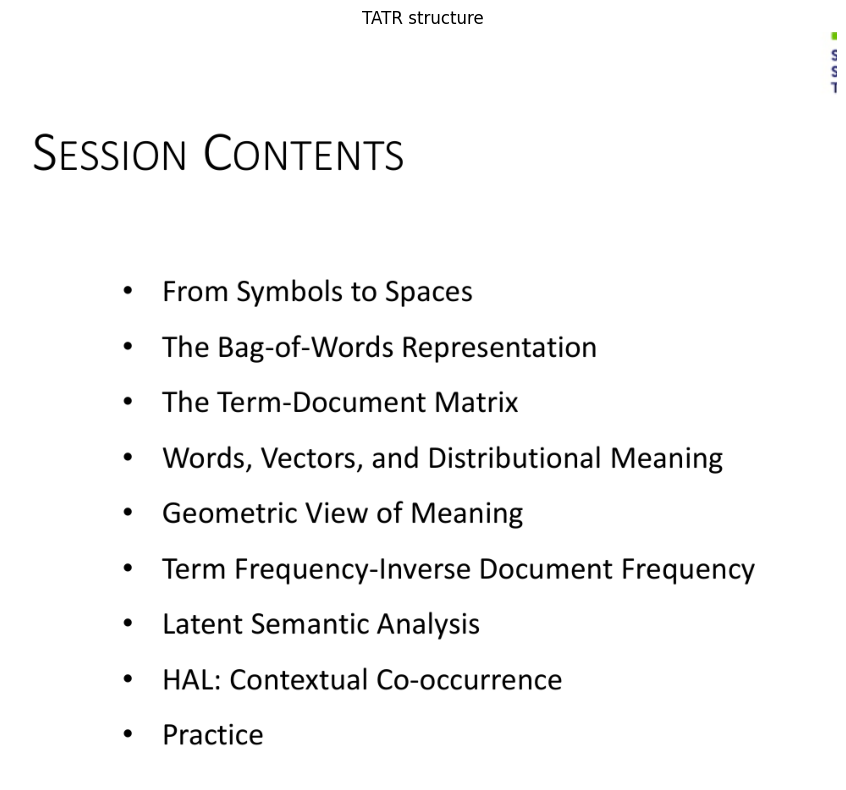

Page 12, table 0
Table box: [278, 300, 1994, 1225]

Raw grid:
['', 'Wildcard, matches any character', 'c.t cut, cat, cot matches or']
['^abc', 'Matches some pattern abc at the start of the string', '^abc abc123 xabc123 matches but not']
['abc$', 'Matches some pattern abc at the end of the string', 'abc$ 123abc 123abcc matches but not']
['[abc]', 'Matches any of a set of character', '[abc] a, b, c matches or']
['[A-Z0-9]', 'Matches any of a range of character', '[a-z0-9] k 7 matches or']
['ed|ing|s', 'Matches one of the specified strings (disjunction)', 'ed|ing|s ed, ing, s matches or']
['', 'Zero or more of previous item (Kleene Closure)', 'ab* a, ab, abb, abbb matches']
['', 'One or more of previous ítem', 'ab+ ab, abb, a matches but not']
['', 'Zero or one of the previous item', 'colou?r color colour matches and']
['', 'Exactly n repeats', '\\d{4} 2025 matches']
['', 'At least n repeats', 'a{2,} aa, aaa, aaaa matches']
['', 'No more than n repeats', 'a{,3} a, aa, aaa matches']
['n}',

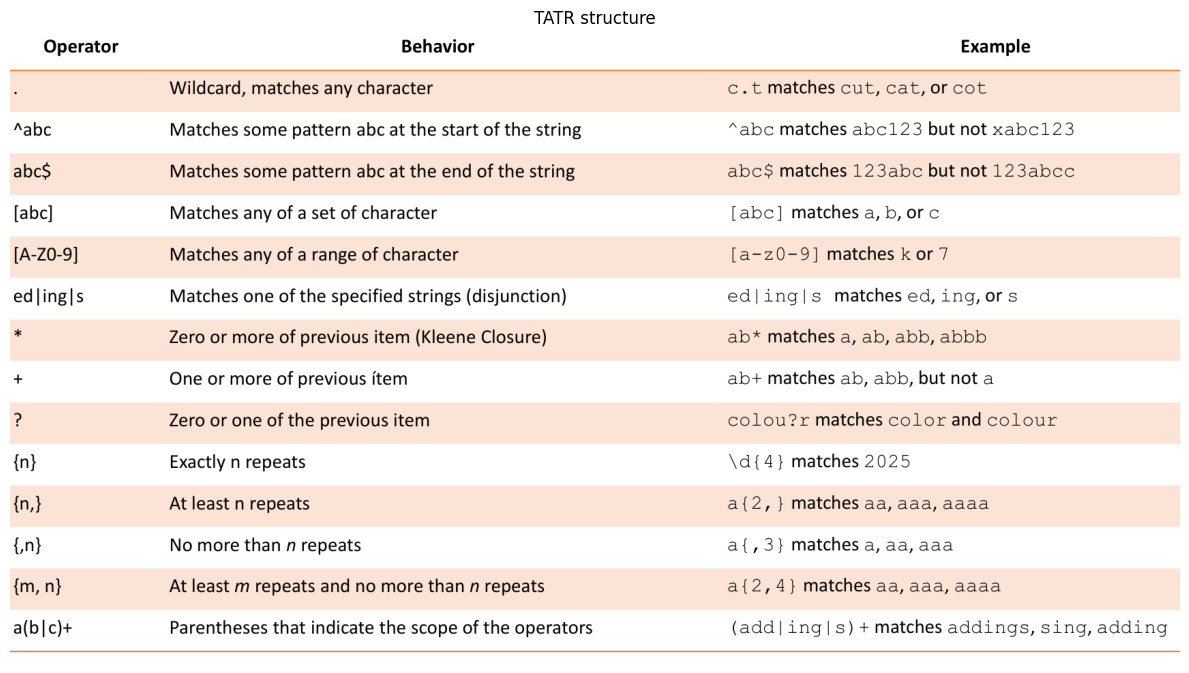

Page 13, table 0
Table box: [1271, 551, 2240, 1166]

Raw grid:
['\\r', 'Carriage return', 'Rare, legacy line breaks']
['\\b', 'Word boundary (position)', '\\bcat\\b cat matches but not']
['\\B', 'Non–word boundary', '\\Bcat scat matches']
['\\A', 'Start of the string', '\\Aabc abc... matches']
['\\Z', 'End of the string', 'abc\\Z ...abc matches']
['\\\\', 'Literal backslash', '\\\\ \\ matches']
['\\.', 'Literal dot', '\\. . matches']
['\\^', 'Literal caret', '\\^ ^ matches']
['\\$', 'Literal dollar sign', '\\$120 $120 matches']

Shape: (9, 3)
Columns: ['col_0', 'col_1', 'col_2']

DataFrame:
  col_0                     col_1                        col_2
0    \r           Carriage return     Rare, legacy line breaks
1    \b  Word boundary (position)  \bcat\b cat matches but not
2    \B         Non–word boundary           \Bcat scat matches
3    \A       Start of the string         \Aabc abc... matches
4    \Z         End of the string         abc\Z ...abc matches


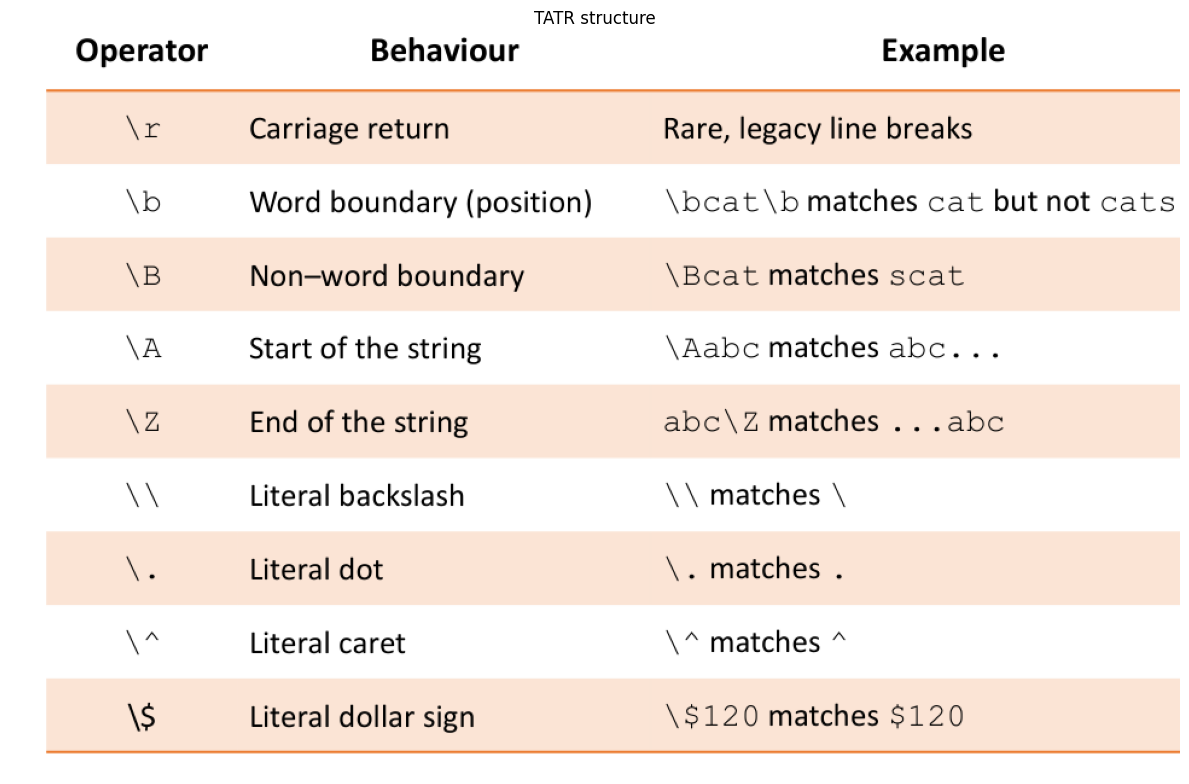

Page 13, table 1
Table box: [118, 545, 1105, 1110]

Raw grid:
['\\d', '(0–9) Any digit', '\\d+ 123 matches']
['\\D', 'Any non-digit', '\\D+ abc matches']
['\\w', 'Any word character (letters, digits, underscore)', '\\w+ user_42 matches']
['\\W', 'Any non-word character', '\\W+ @#$ matches']
['\\s', 'Any whitespace character (space, tab, newline)', '\\s+ matches spaces']
['\\S', 'Any non-whitespace character', '\\S+ text matches']
['\\n', 'Newline character', '\\n matches line breaks']
['\\t', 'Tab character', '\\t matches tabs']

Shape: (8, 3)
Columns: ['col_0', 'col_1', 'col_2']

DataFrame:
  col_0                                             col_1                col_2
0    \d                                   (0–9) Any digit      \d+ 123 matches
1    \D                                     Any non-digit      \D+ abc matches
2    \w  Any word character (letters, digits, underscore)  \w+ user_42 matches
3    \W                            Any non-word character      \W+ @#$ matches
4    \

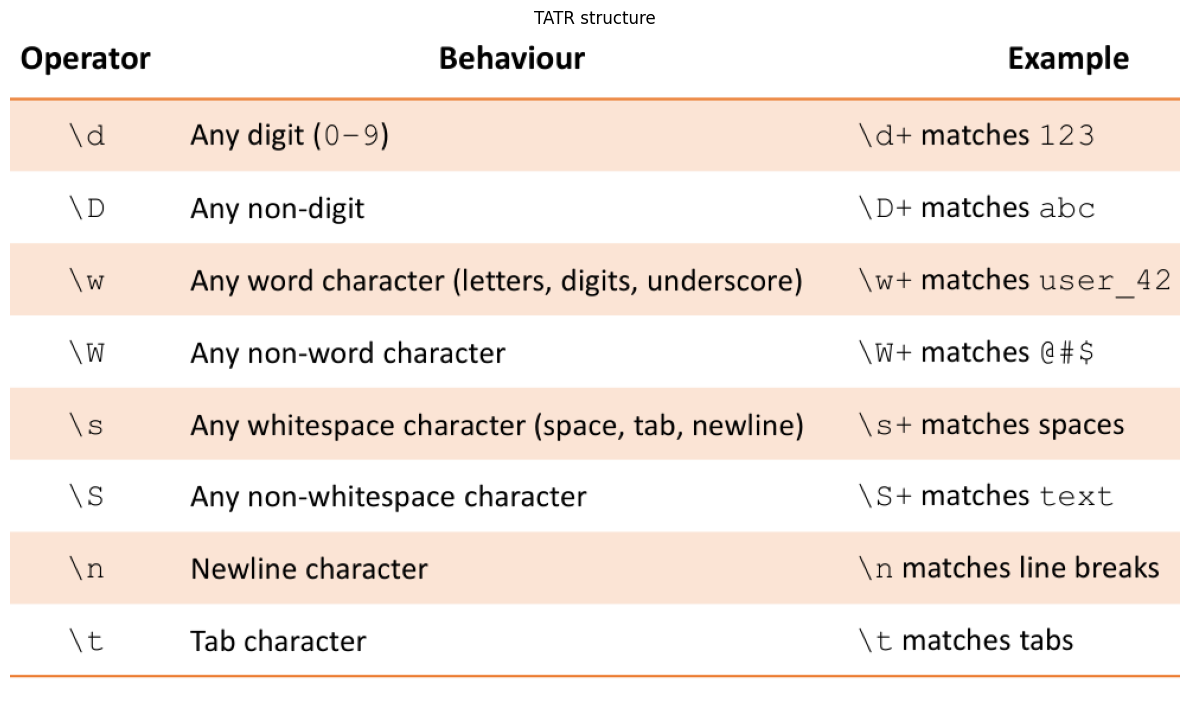

Page 14, table 0
Table box: [233, 742, 1925, 1165]

Raw grid:
['(?=...)', 'Positive lookahead', '\\d(?=%) 5 5% matches in']
['(?!...)', 'Negative lookahead', 'a(?!n) a apple matches in but not in']
['(?<=...)', 'Positive lookbehind', '(?<=\\$)\\d+ 120 $120 matches in']
['(?<!...)', 'Negative lookbehind', '(?<!-)cat cat -cat matches but not']

Shape: (4, 3)
Columns: ['col_0', 'col_1', 'col_2']

DataFrame:
      col_0                col_1                                 col_2
0   (?=...)   Positive lookahead               \d(?=%) 5 5% matches in
1   (?!...)   Negative lookahead  a(?!n) a apple matches in but not in
2  (?<=...)  Positive lookbehind        (?<=\$)\d+ 120 $120 matches in
3  (?<!...)  Negative lookbehind    (?<!-)cat cat -cat matches but not


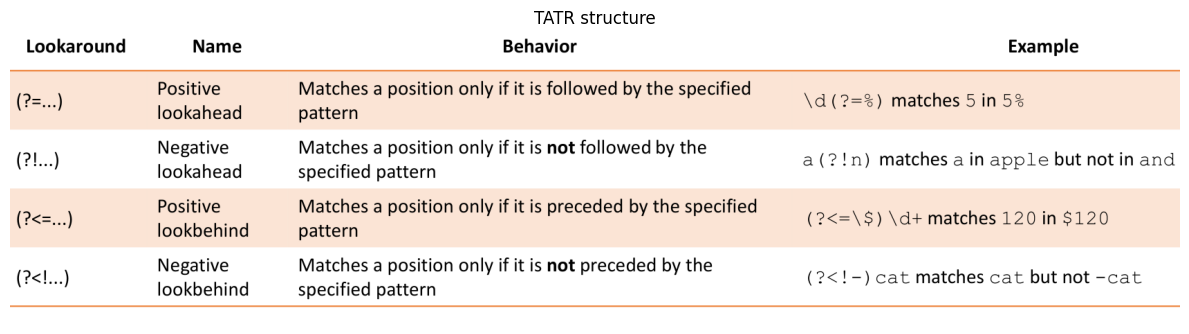

Page 3, table 0: Counter()
Page 12, table 0: Counter()
Page 13, table 0: Counter()
Page 13, table 1: Counter()
Page 14, table 0: Counter()


In [13]:
tables = parse_tables_from_pdf(PDF_PATH)

print(f"\nParsed {len(tables)} table(s).\n")

for t in tables:
    print("=" * 100)
    print(f"Page {t.page_index + 1}, table {t.table_index}")
    print(f"Table box: {t.table_box_page_px}")
    print("\nRaw grid:")
    for row in t.raw_cells:
        print(row)
    print("\nShape:", t.dataframe.shape)
    print("Columns:", list(t.dataframe.columns))
    
    print("\nDataFrame:")
    print(t.dataframe.head())
    visualize_structure(table_img=t.table_box_crop, structure=t.structure_objects)

from collections import Counter

for t in tables:
    counts = Counter(obj.label for obj in t.structure_objects)
    print(f"Page {t.page_index+1}, table {t.table_index}: {counts}")


# Optional: save outputs
for i, t in enumerate(tables):
    t.dataframe.to_csv(f"table_{i+1}_page_{t.page_index+1}.csv", index=False)